## 1. Title & Objective

# AI Risk Manager

### Baseline Fraud Detection Model

Build, compare, and evaluate fraud-risk models using a leakage-safe validation and held-out test workflow.


## 2. Imports

Libraries used for data handling, modelling, evaluation, visualization, persistence, and explainability.


In [5]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier


## 3. Load Train/Test Data

Load the preprocessed train/test split and its fitted scaler. The test set remains untouched during model selection.


In [6]:
split_data = joblib.load("../models/train_test_split.pkl")
X_train, X_test = split_data["X_train"], split_data["X_test"]
y_train, y_test = split_data["y_train"], split_data["y_test"]
scaler = joblib.load("../models/scaler.pkl")
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Training data:", X_train_scaled.shape)
print("Held-out test data:", X_test_scaled.shape)


Training data: (226980, 30)
Held-out test data: (56746, 30)


## 4. Create Validation Split

Split the training data into model-training and validation subsets for unbiased model and threshold selection.


In [7]:
X_model_train, X_val, y_model_train, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.20, random_state=42, stratify=y_train
)
print("Model-training data:", X_model_train.shape)
print("Validation data:", X_val.shape)
print("Held-out test data:", X_test_scaled.shape)


Model-training data: (181584, 30)
Validation data: (45396, 30)
Held-out test data: (56746, 30)


## 5. Evaluation Metrics

Use precision, recall, F1, ROC-AUC, PR-AUC, confusion matrices, and cost-sensitive errors because fraud detection is imbalanced.


In [8]:
# Relative prototype costs for validation threshold selection.
FP_COST = 1
FN_COST = 10


## 6. Logistic Regression Baseline

Train a class-weighted linear baseline on the model-training subset.


In [9]:
baseline_model = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=42
)
baseline_model.fit(X_model_train, y_model_train)
print("Baseline Logistic Regression trained successfully!")


Baseline Logistic Regression trained successfully!


## 7. Logistic Regression Evaluation

Evaluate logistic regression on validation data, including its default-threshold business cost.


In [10]:
# Validation predictions
y_val_pred = baseline_model.predict(X_val)
y_val_proba = baseline_model.predict_proba(X_val)[:, 1]

# Metrics
lr_precision = precision_score(
    y_val,
    y_val_pred,
    zero_division=0
)

lr_recall = recall_score(
    y_val,
    y_val_pred,
    zero_division=0
)

lr_f1 = f1_score(
    y_val,
    y_val_pred,
    zero_division=0
)

lr_roc_auc = roc_auc_score(
    y_val,
    y_val_proba
)

lr_pr_auc = average_precision_score(
    y_val,
    y_val_proba
)

print("=== Logistic Regression Validation Results ===")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1-score  : {lr_f1:.4f}")
print(f"ROC-AUC   : {lr_roc_auc:.4f}")
print(f"PR-AUC    : {lr_pr_auc:.4f}")

print("\n=== Classification Report ===")
print(
    classification_report(
        y_val,
        y_val_pred,
        zero_division=0
    )
)

print("=== Confusion Matrix ===")
print(
    confusion_matrix(
        y_val,
        y_val_pred
    )
)

=== Logistic Regression Validation Results ===
Precision : 0.0542
Recall    : 0.8947
F1-score  : 0.1023
ROC-AUC   : 0.9750
PR-AUC    : 0.8138

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     45320
           1       0.05      0.89      0.10        76

    accuracy                           0.97     45396
   macro avg       0.53      0.93      0.54     45396
weighted avg       1.00      0.97      0.99     45396

=== Confusion Matrix ===
[[44134  1186]
 [    8    68]]


In [11]:
tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(
    y_val,
    y_val_pred
).ravel()

lr_total_cost = (
    fp_lr * FP_COST
    + fn_lr * FN_COST
)

print("True Negatives (TN):", tn_lr)
print("False Positives (FP):", fp_lr)
print("False Negatives (FN):", fn_lr)
print("True Positives (TP):", tp_lr)

print("\nFalse Positive cost:", fp_lr * FP_COST)
print("False Negative cost:", fn_lr * FN_COST)
print("Total validation cost:", lr_total_cost)

True Negatives (TN): 44134
False Positives (FP): 1186
False Negatives (FN): 8
True Positives (TP): 68

False Positive cost: 1186
False Negative cost: 80
Total validation cost: 1266


## 8. Random Forest

Train a nonlinear random-forest candidate on the same training subset.


In [12]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=2,
    class_weight="balanced_subsample", random_state=42, n_jobs=-1
)
rf_model.fit(X_model_train, y_model_train)
print("Random Forest trained successfully!")


Random Forest trained successfully!


## 9. Random Forest Evaluation

Evaluate Random Forest on validation data using identical model and business metrics.


In [13]:
y_val_rf_pred = rf_model.predict(X_val)
y_val_rf_proba = rf_model.predict_proba(X_val)[:, 1]
rf_precision = precision_score(y_val, y_val_rf_pred, zero_division=0)
rf_recall = recall_score(y_val, y_val_rf_pred, zero_division=0)
rf_f1 = f1_score(y_val, y_val_rf_pred, zero_division=0)
rf_roc_auc = roc_auc_score(y_val, y_val_rf_proba)
rf_pr_auc = average_precision_score(y_val, y_val_rf_proba)
print("=== Random Forest Validation Results ===")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")
print(f"PR-AUC    : {rf_pr_auc:.4f}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_rf_pred))


=== Random Forest Validation Results ===
Precision : 0.9143
Recall    : 0.8421
F1-score  : 0.8767
ROC-AUC   : 0.9572
PR-AUC    : 0.8710

Confusion Matrix:
[[45314     6]
 [   12    64]]


In [14]:
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(
    y_val,
    y_val_rf_pred
).ravel()

rf_total_cost = (
    fp_rf * FP_COST
    + fn_rf * FN_COST
)

print("True Negatives (TN):", tn_rf)
print("False Positives (FP):", fp_rf)
print("False Negatives (FN):", fn_rf)
print("True Positives (TP):", tp_rf)

print("\nFalse Positive cost:", fp_rf * FP_COST)
print("False Negative cost:", fn_rf * FN_COST)
print("Total validation cost:", rf_total_cost)

True Negatives (TN): 45314
False Positives (FP): 6
False Negatives (FN): 12
True Positives (TP): 64

False Positive cost: 6
False Negative cost: 120
Total validation cost: 126


## 10. XGBoost

Train a gradient-boosted tree candidate for nonlinear tabular fraud detection.


In [15]:
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, objective="binary:logistic", eval_metric="aucpr",
    random_state=42, n_jobs=-1
)
xgb_model.fit(X_model_train, y_model_train)
print("XGBoost trained successfully!")


XGBoost trained successfully!


## 11. XGBoost Evaluation

Evaluate XGBoost on the validation set before using it in threshold and policy analysis.


In [16]:
# Validation predictions
y_val_xgb_pred = xgb_model.predict(X_val)
y_val_xgb_proba = xgb_model.predict_proba(X_val)[:, 1]

# Metrics
xgb_precision = precision_score(
    y_val,
    y_val_xgb_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_val,
    y_val_xgb_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_val,
    y_val_xgb_pred,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_val,
    y_val_xgb_proba
)

xgb_pr_auc = average_precision_score(
    y_val,
    y_val_xgb_proba
)

print("=== XGBoost Validation Results ===")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1-score  : {xgb_f1:.4f}")
print(f"ROC-AUC   : {xgb_roc_auc:.4f}")
print(f"PR-AUC    : {xgb_pr_auc:.4f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_val, y_val_xgb_pred))

=== XGBoost Validation Results ===
Precision : 0.9841
Recall    : 0.8158
F1-score  : 0.8921
ROC-AUC   : 0.9789
PR-AUC    : 0.8780

=== Confusion Matrix ===
[[45319     1]
 [   14    62]]


In [17]:
tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(
    y_val,
    y_val_xgb_pred
).ravel()

xgb_total_cost = (
    fp_xgb * FP_COST
    + fn_xgb * FN_COST
)

print("True Negatives (TN):", tn_xgb)
print("False Positives (FP):", fp_xgb)
print("False Negatives (FN):", fn_xgb)
print("True Positives (TP):", tp_xgb)

print("\nFalse Positive cost:", fp_xgb * FP_COST)
print("False Negative cost:", fn_xgb * FN_COST)
print("Total validation cost:", xgb_total_cost)

True Negatives (TN): 45319
False Positives (FP): 1
False Negatives (FN): 14
True Positives (TP): 62

False Positive cost: 1
False Negative cost: 140
Total validation cost: 141


## 12. Model Comparison

Compare all candidates on validation performance and their business-cost implications.


In [18]:
model_comparison = pd.DataFrame([
    {"Model": "Logistic Regression", "Precision": lr_precision, "Recall": lr_recall,
     "F1-score": lr_f1, "ROC-AUC": lr_roc_auc, "PR-AUC": lr_pr_auc,
     "Validation Cost": lr_total_cost},
    {"Model": "Random Forest", "Precision": rf_precision, "Recall": rf_recall,
     "F1-score": rf_f1, "ROC-AUC": rf_roc_auc, "PR-AUC": rf_pr_auc,
     "Validation Cost": rf_total_cost},
    {"Model": "XGBoost", "Precision": xgb_precision, "Recall": xgb_recall,
     "F1-score": xgb_f1, "ROC-AUC": xgb_roc_auc, "PR-AUC": xgb_pr_auc,
     "Validation Cost": xgb_total_cost},
])
model_comparison.round(4)


,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Validation Cost
0,Logistic Regression,0.0542,0.8947,0.1023,0.9750,0.8138,1266
1,Random Forest,0.9143,0.8421,0.8767,0.9572,0.8710,126
2,XGBoost,0.9841,0.8158,0.8921,0.9789,0.8780,141


## 13. Threshold Optimization

Validation-only threshold sweep for all candidates. For XGBoost, 0.05 has the lowest prototype cost at FP_COST = 1 and FN_COST = 10 (110 units); 0.20 is close at 111 units but misses one additional fraud. The selected threshold is therefore 0.05.


In [19]:
# Generate validation predictions and probabilities

y_val_pred = baseline_model.predict(
    X_val
)

y_val_proba = baseline_model.predict_proba(
    X_val
)[:, 1]

print("Validation predictions generated successfully!")
print("Validation samples:", len(y_val))

Validation predictions generated successfully!
Validation samples: 45396


In [20]:
threshold_results = []

thresholds = np.arange(0.05, 1.00, 0.05)

for threshold in thresholds:

    y_val_threshold = (
        y_val_proba >= threshold
    ).astype(int)

    precision_value = precision_score(
        y_val,
        y_val_threshold,
        zero_division=0
    )

    recall_value = recall_score(
        y_val,
        y_val_threshold,
        zero_division=0
    )

    f1_value = f1_score(
        y_val,
        y_val_threshold,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_val_threshold
    ).ravel()

    total_cost = (
        fp * FP_COST
        + fn * FN_COST
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_value,
        "recall": recall_value,
        "f1": f1_value,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn,
        "total_cost": total_cost
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,threshold,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives,total_cost
0,0.05,0.005574,0.960526,0.011083,13024,3,73,32296,13054
1,0.10,0.009545,0.947368,0.018900,7471,4,72,37849,7511
2,0.15,0.013780,0.947368,0.027165,5153,4,72,40167,5193
3,0.20,0.017771,0.921053,0.034869,3869,6,70,41451,3929
4,0.25,0.021773,0.907895,0.042527,3100,7,69,42220,3170
5,0.30,0.026911,0.907895,0.052273,2495,7,69,42825,2565
6,0.35,0.033237,0.907895,0.064126,2007,7,69,43313,2077
7,0.40,0.039406,0.907895,0.075534,1682,7,69,43638,1752
8,0.45,0.046433,0.907895,0.088348,1417,7,69,43903,1487
9,0.50,0.054226,0.894737,0.102256,1186,8,68,44134,1266


In [21]:
best_cost_row = threshold_df.loc[
    threshold_df["total_cost"].idxmin()
]

print("Lowest-cost Logistic Regression threshold:")
print(best_cost_row)

Lowest-cost Logistic Regression threshold:
threshold              0.950000
precision              0.366667
recall                 0.868421
f1                     0.515625
false_positives      114.000000
false_negatives       10.000000
true_positives        66.000000
true_negatives     45206.000000
total_cost           214.000000
Name: 18, dtype: float64


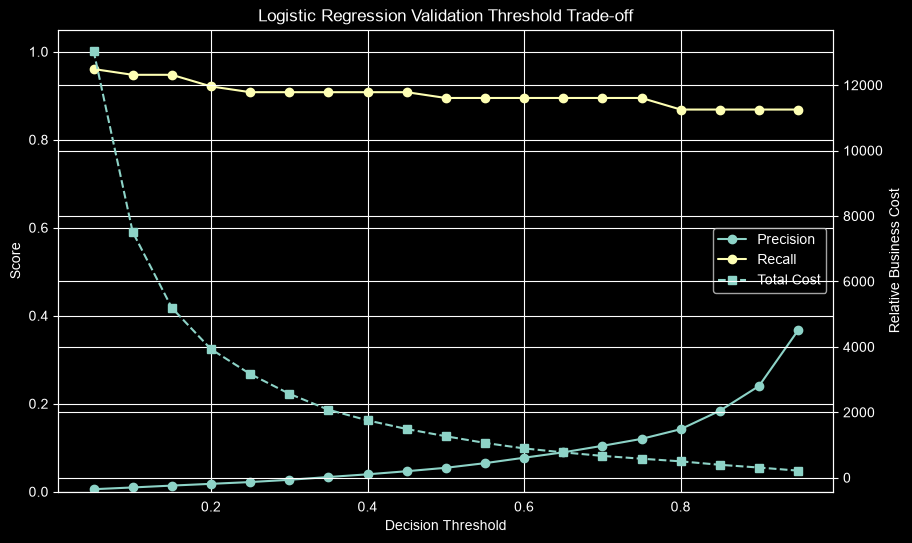

In [22]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
ax1.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
ax1.set_xlabel("Decision Threshold")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.05)
ax2 = ax1.twinx()
ax2.plot(threshold_df["threshold"], threshold_df["total_cost"], marker="s", linestyle="--", label="Total Cost")
ax2.set_ylabel("Relative Business Cost")
ax1.set_title("Logistic Regression Validation Threshold Trade-off")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.show()


In [23]:
rf_threshold_results = []

thresholds = np.arange(0.05, 0.96, 0.05)

for threshold in thresholds:

    y_val_rf_threshold = (
        y_val_rf_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_val_rf_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_rf_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_rf_threshold,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_val_rf_threshold
    ).ravel()

    total_cost = (
        fp * FP_COST
        + fn * FN_COST
    )

    rf_threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn,
        "total_cost": total_cost
    })

rf_threshold_df = pd.DataFrame(
    rf_threshold_results
)

rf_threshold_df

,threshold,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives,total_cost
0,0.05,0.170483,0.881579,0.285714,326,9,67,44994,416
1,0.10,0.411043,0.881579,0.560669,96,9,67,45224,186
2,0.15,0.577586,0.881579,0.697917,49,9,67,45271,139
3,0.20,0.728261,0.881579,0.797619,25,9,67,45295,115
4,0.25,0.767442,0.868421,0.814815,20,10,66,45300,120
5,0.30,0.833333,0.855263,0.844156,13,11,65,45307,123
6,0.35,0.890411,0.855263,0.872483,8,11,65,45312,118
7,0.40,0.890411,0.855263,0.872483,8,11,65,45312,118
8,0.45,0.901408,0.842105,0.870748,7,12,64,45313,127
9,0.50,0.914286,0.842105,0.876712,6,12,64,45314,126


In [24]:
best_rf_cost_row = rf_threshold_df.loc[
    rf_threshold_df["total_cost"].idxmin()
]

print("Lowest-cost Random Forest threshold:")
print(best_rf_cost_row)

Lowest-cost Random Forest threshold:
threshold              0.200000
precision              0.728261
recall                 0.881579
f1                     0.797619
false_positives       25.000000
false_negatives        9.000000
true_positives        67.000000
true_negatives     45295.000000
total_cost           115.000000
Name: 3, dtype: float64


In [25]:
xgb_threshold_results = []

thresholds = np.arange(0.05, 0.96, 0.05)

for threshold in thresholds:

    y_val_xgb_threshold = (
        y_val_xgb_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_val_xgb_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_xgb_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_xgb_threshold,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_val_xgb_threshold
    ).ravel()

    total_cost = (
        fp * FP_COST
        + fn * FN_COST
    )

    xgb_threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn,
        "total_cost": total_cost
    })

xgb_threshold_df = pd.DataFrame(
    xgb_threshold_results
)

xgb_threshold_df

,threshold,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives,total_cost
0,0.05,0.868421,0.868421,0.868421,10,10,66,45310,110
1,0.10,0.942029,0.855263,0.896552,4,11,65,45316,114
2,0.15,0.970149,0.855263,0.909091,2,11,65,45318,112
3,0.20,0.984848,0.855263,0.915493,1,11,65,45319,111
4,0.25,0.984615,0.842105,0.907801,1,12,64,45319,121
5,0.30,0.984615,0.842105,0.907801,1,12,64,45319,121
6,0.35,0.984375,0.828947,0.900000,1,13,63,45319,131
7,0.40,0.984127,0.815789,0.892086,1,14,62,45319,141
8,0.45,0.984127,0.815789,0.892086,1,14,62,45319,141
9,0.50,0.984127,0.815789,0.892086,1,14,62,45319,141


In [26]:
best_xgb_cost_row = xgb_threshold_df.loc[
    xgb_threshold_df["total_cost"].idxmin()
]

print("Lowest-cost XGBoost threshold:")
print(best_xgb_cost_row)


Lowest-cost XGBoost threshold:
threshold              0.050000
precision              0.868421
recall                 0.868421
f1                     0.868421
false_positives       10.000000
false_negatives       10.000000
true_positives        66.000000
true_negatives     45310.000000
total_cost           110.000000
Name: 0, dtype: float64


## 14. Cost Sensitivity Analysis

Test how the preferred model's threshold choice changes as the cost of missed fraud increases.


In [27]:
cost_ratios = [1, 2, 5, 10, 20, 50]

cost_sensitivity_results = []

for ratio in cost_ratios:

    costs = (
        xgb_threshold_df["false_positives"] * 1
        + xgb_threshold_df["false_negatives"] * ratio
    )

    best_idx = costs.idxmin()
    best_row = xgb_threshold_df.loc[best_idx]

    cost_sensitivity_results.append({
        "FN_to_FP_Ratio": f"{ratio}:1",
        "Best_Threshold": best_row["threshold"],
        "Precision": best_row["precision"],
        "Recall": best_row["recall"],
        "F1": best_row["f1"],
        "False_Positives": best_row["false_positives"],
        "False_Negatives": best_row["false_negatives"],
        "Minimum_Cost": costs.loc[best_idx]
    })

cost_sensitivity_df = pd.DataFrame(
    cost_sensitivity_results
)

cost_sensitivity_df.round(4)

,FN_to_FP_Ratio,Best_Threshold,Precision,Recall,F1,False_Positives,False_Negatives,Minimum_Cost
0,1:1,0.20,0.9848,0.8553,0.9155,1.0,11.0,12
1,2:1,0.20,0.9848,0.8553,0.9155,1.0,11.0,23
2,5:1,0.20,0.9848,0.8553,0.9155,1.0,11.0,56
3,10:1,0.05,0.8684,0.8684,0.8684,10.0,10.0,110
4,20:1,0.05,0.8684,0.8684,0.8684,10.0,10.0,210
5,50:1,0.05,0.8684,0.8684,0.8684,10.0,10.0,510


## 15. Final Risk Decision Policy

Translate fraud probabilities into operational LOW/APPROVE, MEDIUM/REVIEW, and HIGH/BLOCK decisions; assess validation routing.


In [28]:
def risk_decision(fraud_probability):
    if fraud_probability < 0.05:
        return "LOW", "APPROVE"
    elif fraud_probability < 0.20:
        return "MEDIUM", "REVIEW"
    else:
        return "HIGH", "BLOCK"


# Example predictions
example_probabilities = [0.01, 0.08, 0.35, 0.92]

for probability in example_probabilities:
    risk_level, action = risk_decision(probability)

    print(
        f"Fraud Probability: {probability:.2f} "
        f"| Risk: {risk_level} "
        f"| Action: {action}"
    )

Fraud Probability: 0.01 | Risk: LOW | Action: APPROVE
Fraud Probability: 0.08 | Risk: MEDIUM | Action: REVIEW
Fraud Probability: 0.35 | Risk: HIGH | Action: BLOCK
Fraud Probability: 0.92 | Risk: HIGH | Action: BLOCK


In [29]:
validation_risk_results = []

for probability in y_val_xgb_proba:

    risk_level, action = risk_decision(probability)

    validation_risk_results.append({
        "fraud_probability": probability,
        "risk_level": risk_level,
        "action": action
    })

validation_risk_df = pd.DataFrame(
    validation_risk_results
)

print("Risk distribution:")
print(
    validation_risk_df["risk_level"]
    .value_counts()
)

print("\nAction distribution:")
print(
    validation_risk_df["action"]
    .value_counts()
)

Risk distribution:
risk_level
LOW       45320
HIGH         66
MEDIUM       10
Name: count, dtype: int64

Action distribution:
action
APPROVE    45320
BLOCK         66
REVIEW        10
Name: count, dtype: int64


In [30]:
validation_risk_df["actual_class"] = y_val.to_numpy()

fraud_by_risk = (
    validation_risk_df
    .groupby(["risk_level", "action"])["actual_class"]
    .agg(
        total_transactions="count",
        fraud_transactions="sum"
    )
    .reset_index()
)

fraud_by_risk["fraud_rate"] = (
    fraud_by_risk["fraud_transactions"]
    / fraud_by_risk["total_transactions"]
    * 100
)

fraud_by_risk

,risk_level,action,total_transactions,fraud_transactions,fraud_rate
0,HIGH,BLOCK,66,65,98.484848
1,LOW,APPROVE,45320,10,0.022065
2,MEDIUM,REVIEW,10,1,10.000000


In [31]:
total_fraud = validation_risk_df["actual_class"].sum()

blocked_fraud = (
    validation_risk_df[
        validation_risk_df["action"] == "BLOCK"
    ]["actual_class"].sum()
)

reviewed_fraud = (
    validation_risk_df[
        validation_risk_df["action"] == "REVIEW"
    ]["actual_class"].sum()
)

approved_fraud = (
    validation_risk_df[
        validation_risk_df["action"] == "APPROVE"
    ]["actual_class"].sum()
)

block_capture_rate = (
    blocked_fraud / total_fraud * 100
)

block_review_capture_rate = (
    (blocked_fraud + reviewed_fraud)
    / total_fraud * 100
)

fraud_leakage_rate = (
    approved_fraud / total_fraud * 100
)

print("Total fraud:", total_fraud)

print(
    f"\nBlock Capture Rate: "
    f"{block_capture_rate:.2f}%"
)

print(
    f"Block + Review Capture Rate: "
    f"{block_review_capture_rate:.2f}%"
)

print(
    f"Fraud Leakage Rate: "
    f"{fraud_leakage_rate:.2f}%"
)

Total fraud: 76

Block Capture Rate: 85.53%
Block + Review Capture Rate: 86.84%
Fraud Leakage Rate: 13.16%


## 16. Save Candidate Model

Persist the leading candidate and its supporting metadata for downstream use.


In [32]:
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)
joblib.dump(xgb_model, models_dir / "xgboost_candidate.pkl")
risk_policy = {
    "model": "XGBoost", "threshold_high": 0.20,
    "threshold_medium": 0.05, "cost_ratio_fn_to_fp": 10,
}
joblib.dump(risk_policy, models_dir / "risk_policy.pkl")
print("Candidate XGBoost model and risk policy saved.")


Candidate XGBoost model and risk policy saved.


## 17. Final Held-Out Test Evaluation

Evaluate the selected XGBoost model once on the untouched test set using the validation-selected threshold.


In [33]:
# Test data is used only here, after validation-based model selection.
y_test_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
FINAL_THRESHOLD = 0.05
y_test_pred = (y_test_proba >= FINAL_THRESHOLD).astype(int)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)
tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, y_test_pred).ravel()
print("=== FINAL HELD-OUT TEST RESULTS ===")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1-score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_roc_auc:.4f}")
print(f"PR-AUC    : {test_pr_auc:.4f}")
print()
print("Confusion Matrix")
print(f"TN: {tn_test} | FP: {fp_test} | FN: {fn_test} | TP: {tp_test}")


=== FINAL HELD-OUT TEST RESULTS ===
Precision : 0.8280
Recall    : 0.8105
F1-score  : 0.8191
ROC-AUC   : 0.9775
PR-AUC    : 0.8292

Confusion Matrix
TN: 56635 | FP: 16 | FN: 18 | TP: 77


In [34]:
# Report the single held-out evaluation calculated in the preceding cell.
total_test_transactions = len(y_test)
total_test_fraud = int(y_test.sum())
fraud_capture_rate = test_recall * 100
fraud_leakage_rate = fn_test / total_test_fraud * 100 if total_test_fraud else 0.0
false_positive_rate = fp_test / (tn_test + fp_test) * 100 if (tn_test + fp_test) else 0.0

# Prototype relative-cost assumptions, not actual Razorpay or merchant losses.
false_positive_cost = fp_test * FP_COST
false_negative_cost = fn_test * FN_COST
test_cost = false_positive_cost + false_negative_cost

print("=" * 55)
print("FINAL HELD-OUT TEST EVALUATION")
print("=" * 55)
print(f"Final Threshold      : {FINAL_THRESHOLD:.2f}")
print(f"Total Transactions   : {total_test_transactions}")
print(f"Total Fraud          : {total_test_fraud}")
print(f"True Negatives       : {tn_test}")
print(f"False Positives      : {fp_test}")
print(f"False Negatives      : {fn_test}")
print(f"True Positives       : {tp_test}")
print(f"Precision            : {test_precision:.4f}")
print(f"Recall               : {test_recall:.4f}")
print(f"F1 Score             : {test_f1:.4f}")
print(f"ROC-AUC              : {test_roc_auc:.4f}")
print(f"PR-AUC               : {test_pr_auc:.4f}")
print(f"Fraud Capture Rate   : {fraud_capture_rate:.2f}%")
print(f"Fraud Leakage Rate   : {fraud_leakage_rate:.2f}%")
print(f"False Positive Rate  : {false_positive_rate:.4f}%")
print(f"Prototype Cost (1:10): {test_cost} cost units")


FINAL HELD-OUT TEST EVALUATION
Final Threshold      : 0.05
Total Transactions   : 56746
Total Fraud          : 95
True Negatives       : 56635
False Positives      : 16
False Negatives      : 18
True Positives       : 77
Precision            : 0.8280
Recall               : 0.8105
F1 Score             : 0.8191
ROC-AUC              : 0.9775
PR-AUC               : 0.8292
Fraud Capture Rate   : 81.05%
Fraud Leakage Rate   : 18.95%
False Positive Rate  : 0.0282%
Prototype Cost (1:10): 196 cost units


## 18. Final Risk Policy KPIs

Measure test-set fraud routing, capture, leakage, and operational volumes under the unchanged risk policy.


In [35]:
# Apply the previously selected risk policy
test_risk_results = []

for probability in y_test_proba:

    risk_level, action = risk_decision(probability)

    test_risk_results.append({
        "fraud_probability": probability,
        "risk_level": risk_level,
        "action": action
    })

test_risk_df = pd.DataFrame(
    test_risk_results
)

# Add actual fraud label
test_risk_df["actual_class"] = y_test.to_numpy()

print("Test risk distribution:")
print(
    test_risk_df["risk_level"]
    .value_counts()
)

print("\nTest action distribution:")
print(
    test_risk_df["action"]
    .value_counts()
)

Test risk distribution:
risk_level
LOW       56653
HIGH         75
MEDIUM       18
Name: count, dtype: int64

Test action distribution:
action
APPROVE    56653
BLOCK         75
REVIEW        18
Name: count, dtype: int64


In [36]:
test_fraud_by_risk = (
    test_risk_df
    .groupby(["risk_level", "action"])["actual_class"]
    .agg(
        total_transactions="count",
        fraud_transactions="sum"
    )
    .reset_index()
)

test_fraud_by_risk["fraud_rate"] = (
    test_fraud_by_risk["fraud_transactions"]
    / test_fraud_by_risk["total_transactions"]
    * 100
)

test_fraud_by_risk

,risk_level,action,total_transactions,fraud_transactions,fraud_rate
0,HIGH,BLOCK,75,73,97.333333
1,LOW,APPROVE,56653,18,0.031772
2,MEDIUM,REVIEW,18,4,22.222222


In [37]:
total_test_fraud = int(test_risk_df["actual_class"].sum())
total_legitimate = int((test_risk_df["actual_class"] == 0).sum())

def routed_count(action, actual_class):
    return int(((test_risk_df["action"] == action) &
                (test_risk_df["actual_class"] == actual_class)).sum())

approved_fraud = routed_count("APPROVE", 1)
reviewed_fraud = routed_count("REVIEW", 1)
blocked_fraud = routed_count("BLOCK", 1)
approved_legitimate = routed_count("APPROVE", 0)
reviewed_legitimate = routed_count("REVIEW", 0)
blocked_legitimate = routed_count("BLOCK", 0)

block_capture_rate = blocked_fraud / total_test_fraud * 100
block_review_capture_rate = (blocked_fraud + reviewed_fraud) / total_test_fraud * 100
fraud_leakage_rate = approved_fraud / total_test_fraud * 100

print("=== FINAL TEST RISK POLICY KPIs ===")
print(f"Block Capture Rate        : {block_capture_rate:.2f}%")
print(f"Block + Review Capture    : {block_review_capture_rate:.2f}%")
print(f"Fraud Leakage Rate        : {fraud_leakage_rate:.2f}%")
print("\nFraud routing")
print(f"APPROVE: {approved_fraud} | REVIEW: {reviewed_fraud} | BLOCK: {blocked_fraud}")
print("Legitimate-transaction routing")
print(f"APPROVE: {approved_legitimate} | REVIEW: {reviewed_legitimate} | BLOCK: {blocked_legitimate}")


=== FINAL TEST RISK POLICY KPIs ===
Block Capture Rate        : 76.84%
Block + Review Capture    : 81.05%
Fraud Leakage Rate        : 18.95%

Fraud routing
APPROVE: 18 | REVIEW: 4 | BLOCK: 73
Legitimate-transaction routing
APPROVE: 56635 | REVIEW: 14 | BLOCK: 2


## 19. Business Cost Analysis

Prototype relative-cost view at the unchanged validation-selected threshold. These cost units are illustrative rather than actual Razorpay or merchant losses.


In [38]:
# Reuse the held-out evaluation's transparent 1:10 prototype cost calculation.
print("=== PROTOTYPE BUSINESS COST ANALYSIS ===")
print("Assumptions: FP_COST = 1, FN_COST = 10 cost units.")
print("These relative costs are illustrative, not actual Razorpay or merchant losses.")
print(f"False-positive cost: {false_positive_cost} cost units")
print(f"False-negative cost: {false_negative_cost} cost units")
print(f"Total prototype cost: {test_cost} cost units")


=== PROTOTYPE BUSINESS COST ANALYSIS ===
Assumptions: FP_COST = 1, FN_COST = 10 cost units.
These relative costs are illustrative, not actual Razorpay or merchant losses.
False-positive cost: 16 cost units
False-negative cost: 180 cost units
Total prototype cost: 196 cost units


## 20. API Prediction Function

Provide reusable inference helpers and verify them with normal and fraudulent held-out transactions.


In [39]:
def predict_fraud_risk(transaction_features):

    # Convert input to DataFrame
    input_df = pd.DataFrame(
        [transaction_features]
    )

    # Scale features using the existing scaler
    input_scaled = scaler.transform(
        input_df
    )

    # Predict fraud probability
    fraud_probability = xgb_model.predict_proba(
        input_scaled
    )[0, 1]

    # Apply risk policy
    risk_level, action = risk_decision(
        fraud_probability
    )

    return {
        "fraud_probability": float(
            fraud_probability
        ),
        "risk_level": risk_level,
        "action": action
    }

In [40]:
# Select one transaction from the test set
sample_transaction = X_test.iloc[0]

# Convert it to a dictionary
sample_features = sample_transaction.to_dict()

# Generate risk prediction
prediction_result = predict_fraud_risk(
    sample_features
)

print("Prediction Result:")
print(prediction_result)

print("\nActual Class:")
print(y_test.iloc[0])


{'fraud_probability': 6.386791028489824e-06, 'risk_level': 'LOW', 'action': 'APPROVE'}

Actual Class:
0


In [41]:
# Find the first actual fraud transaction in the test set
fraud_index = y_test[y_test == 1].index[0]

# Get its features
fraud_transaction = X_test.loc[fraud_index]

# Convert features to dictionary
fraud_features = fraud_transaction.to_dict()

# Generate prediction
fraud_prediction = predict_fraud_risk(
    fraud_features
)

print("Fraud Transaction Prediction:")
print(fraud_prediction)

print("\nActual Class:")
print(y_test.loc[fraud_index])

Fraud Transaction Prediction:
{'fraud_probability': 0.9007330536842346, 'risk_level': 'HIGH', 'action': 'BLOCK'}

Actual Class:
1


## 21. API Input Schema

Define, validate, and serialize the feature contract for a production prediction API.


In [42]:
MODEL_FEATURES = [
    "Time",
    "V1", "V2", "V3", "V4", "V5",
    "V6", "V7", "V8", "V9", "V10",
    "V11", "V12", "V13", "V14", "V15",
    "V16", "V17", "V18", "V19", "V20",
    "V21", "V22", "V23", "V24", "V25",
    "V26", "V27", "V28",
    "Amount"
]

print("Number of model input features:", len(MODEL_FEATURES))
print(MODEL_FEATURES)

Number of model input features: 30
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [43]:
def validate_transaction_input(transaction_features):

    input_features = list(transaction_features.keys())

    missing_features = [
        feature
        for feature in MODEL_FEATURES
        if feature not in input_features
    ]

    unexpected_features = [
        feature
        for feature in input_features
        if feature not in MODEL_FEATURES
    ]

    if missing_features:
        raise ValueError(
            f"Missing features: {missing_features}"
        )

    if unexpected_features:
        raise ValueError(
            f"Unexpected features: {unexpected_features}"
        )

    return True


# Test using our previous legitimate transaction
validate_transaction_input(sample_features)

print("API input validation successful!")

API input validation successful!


In [44]:
def predict_transaction(transaction_features):

    # Validate input
    validate_transaction_input(
        transaction_features
    )

    # Generate prediction
    result = predict_fraud_risk(
        transaction_features
    )

    return {
        "fraud_probability": round(
            result["fraud_probability"], 4
        ),
        "risk_level": result["risk_level"],
        "action": result["action"]
    }


# Test API-style response
api_result = predict_transaction(
    sample_features
)

print(api_result)

{'fraud_probability': 0.0, 'risk_level': 'LOW', 'action': 'APPROVE'}


In [45]:
fraud_api_sample = X_test.loc[fraud_index].to_dict()

fraud_api_sample

{'Time': 74159.0,
 'V1': -1.54878809850026,
 'V2': 1.80869795041448,
 'V3': -0.953509033832342,
 'V4': 2.21308539346999,
 'V5': -2.01572779170327,
 'V6': -0.913456844516923,
 'V7': -2.35601298316433,
 'V8': 1.19716896702387,
 'V9': -1.67837405659509,
 'V10': -3.53865023182429,
 'V11': 3.1020899271543,
 'V12': -3.99337305447702,
 'V13': -1.93741062327519,
 'V14': -3.82289410599595,
 'V15': 0.830970110708369,
 'V16': -2.47535885382925,
 'V17': -5.21187516766885,
 'V18': -0.413871678166879,
 'V19': 0.933262164554872,
 'V20': 0.390785963777347,
 'V21': 0.855138263312025,
 'V22': 0.77474482148342,
 'V23': 0.0590371520063436,
 'V24': 0.343199807900813,
 'V25': -0.468937928609185,
 'V26': -0.278337986906642,
 'V27': 0.625922215184372,
 'V28': 0.395573378256676,
 'Amount': 76.94}

## 22. SHAP Explainability

Generate local SHAP attributions for a fraud example and identify its most influential features.


In [46]:
explainer = shap.TreeExplainer(xgb_model)

print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [47]:
# Feature order used by the model
feature_columns = [
    "Time",
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6",
    "V7",
    "V8",
    "V9",
    "V10",
    "V11",
    "V12",
    "V13",
    "V14",
    "V15",
    "V16",
    "V17",
    "V18",
    "V19",
    "V20",
    "V21",
    "V22",
    "V23",
    "V24",
    "V25",
    "V26",
    "V27",
    "V28",
    "Amount"
]

fraud_df = pd.DataFrame(
    [fraud_api_sample]
)[feature_columns]

print("Fraud transaction prepared successfully!")
print("Shape:", fraud_df.shape)

Fraud transaction prepared successfully!
Shape: (1, 30)


In [48]:
fraud_scaled = scaler.transform(
    fraud_df
)

print("Fraud transaction scaled successfully!")
print("Shape:", fraud_scaled.shape)

Fraud transaction scaled successfully!
Shape: (1, 30)


In [49]:
shap_values = explainer(
    fraud_scaled
)

print("SHAP values calculated successfully!")
print("Shape:", shap_values.values.shape)


Shape: (1, 30)


In [50]:
shap_importance = pd.DataFrame({
    "feature": feature_columns,
    "shap_value": shap_values.values[0]
})

shap_importance["absolute_shap"] = (
    shap_importance["shap_value"].abs()
)

shap_importance = shap_importance.sort_values(
    "absolute_shap",
    ascending=False
)

shap_importance.head(10)

,feature,shap_value,absolute_shap
14,V14,3.978881,3.978881
10,V10,2.251323,2.251323
12,V12,1.216597,1.216597
4,V4,0.829447,0.829447
28,V28,-0.721725,0.721725
26,V26,-0.606261,0.606261
16,V16,0.605726,0.605726
7,V7,0.524191,0.524191
15,V15,-0.462443,0.462443
17,V17,0.446086,0.446086


In [51]:
top_shap_features = (
    shap_importance
    .head(5)
    [["feature", "shap_value"]]
    .to_dict(orient="records")
)

top_shap_features

[{'feature': 'V14', 'shap_value': 3.9788806438446045},
 {'feature': 'V10', 'shap_value': 2.2513225078582764},
 {'feature': 'V12', 'shap_value': 1.2165966033935547},
 {'feature': 'V4', 'shap_value': 0.8294472098350525},
 {'feature': 'V28', 'shap_value': -0.721724808216095}]

## 23. SHAP Waterfall

Visualize the selected transaction's feature contributions to the model score.


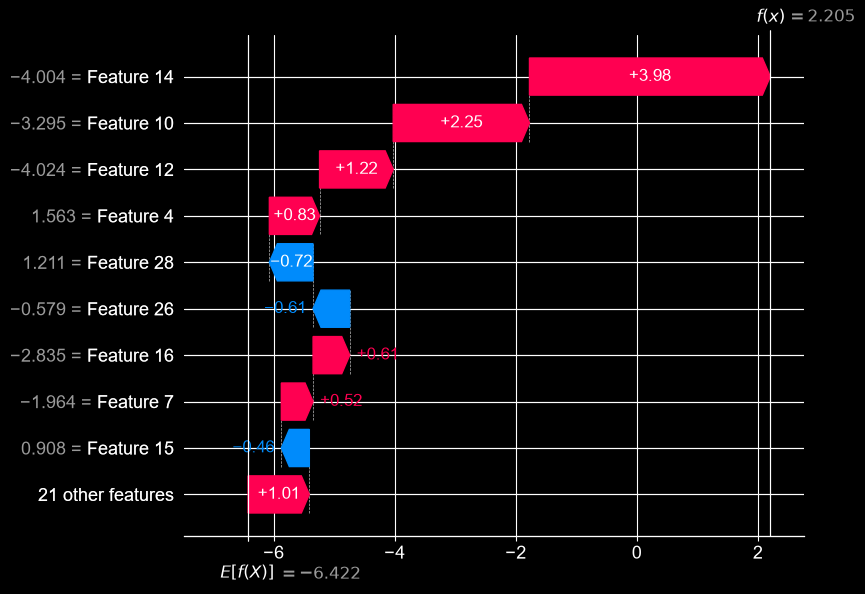

In [52]:
shap.plots.waterfall(shap_values[0], max_display=10)
plt.show()


## 24. Final Conclusion

XGBoost is the selected candidate, with the 0.05 threshold chosen using validation data only. On the untouched test set, the final policy reports 81.05% fraud capture, 18.95% fraud leakage, and a 0.0282% false-positive rate (77 TP, 16 FP, 18 FN, and 56,635 TN). SHAP provides local explainability, while the APPROVE / REVIEW / BLOCK policy supports operational routing. Business costs use prototype assumptions only, not actual merchant losses.
